<a href="https://colab.research.google.com/github/JF11579/PSID_For_the_Rest_of_US/blob/main/03_Exploration_Robustness_CORRECTED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 PSID Exploration & Robustness Checks

## What This Notebook Does

After finding that homeownership is associated with ~1 year more child education, we naturally wonder:

**"Is this finding robust? Does it hold across different groups? What else can we learn from the data?"**

### The Goal

This notebook explores the data more deeply and tests the robustness of our main finding through:

1. **Family Structure Analysis** — How many children did G1 families have?
2. **Subgroup Analyses** — Does the effect vary by race? By sex?
3. **Cohort Analysis** — Does the effect differ by birth decade?
4. **Missing Data Patterns** — Who's missing from our analysis?
5. **Alternative Specifications** — Different age cutoffs, model variations

**Why This Matters:**

- **Robustness** — Does our finding hold under different assumptions?
- **Generalizability** — Does the effect apply to all groups?
- **Understanding** — What factors moderate or mediate the effect?

---

## 🔑 Key Concepts

### What is a "Robustness Check"?

**Simple explanation:**
"Testing whether your main finding still holds when you change how you analyze the data."

**Example:**
- Main analysis: Age ≥ 25
- Robustness: Try age ≥ 21, 23, 30
- If results stay similar → Finding is "robust"

### What is a "Subgroup Analysis"?

**Simple explanation:**
"Checking if the effect differs for different groups of people."

**Example:**
- Does homeownership matter more for Black families?
- Is the effect stronger for children born in certain decades?

---


# Part 1: Setup

Same libraries and data path as Notebook 02. We load two files:
- **`psid_intergenerational_clean.csv`** — the main analytic sample (complete cases, age ≥ 25)
- **`psid_intergenerational_clean_prefilt.csv`** — the pre-filter version (before dropping incomplete cases), used for the missing data analysis in Part 4

---


In [ ]:
# ── Libraries ──
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ── Style ──
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

print("✅ Libraries loaded!")


✅ Libraries loaded!


In [ ]:
# ── Mount Google Drive (Colab only) ──
from google.colab import drive
drive.mount('/content/drive')

# ── Paths (same as Notebook 02) ──
BASE = '/content/drive/MyDrive/Colab Notebooks/Projects/PSID/PSID_2026/PSID_book_v2'
DATA_DIR = f'{BASE}/data'
OUTPUT_DIR = f'{BASE}/outputs'

INPUT_FILE = f'{OUTPUT_DIR}/psid_intergenerational_clean.csv'
PREFILT_FILE = f'{OUTPUT_DIR}/psid_intergenerational_clean_prefilt.csv'

# ── Verify ──
if not os.path.exists(BASE):
    print(f'ERROR: BASE path not found: {BASE}')
else:
    print(f'BASE path OK: {BASE}')
    print(f'Files in outputs/: {os.listdir(OUTPUT_DIR)}')


Mounted at /content/drive
BASE path OK: /content/drive/MyDrive/Colab Notebooks/Projects/PSID/PSID_2026/PSID_book_v2
Files in outputs/: ['psid_intergenerational_clean.csv', 'psid_intergenerational_clean_prefilt.csv', 'table2_education_regressions.csv', 'table3_homeownership_regressions.csv', 'fig2_homeownership_by_race.png', 'fig1_homeownership_by_parent_status.png', 'table3_homeownership_regression_plain.csv', 'table1_summary_stats.csv', 'table2_education_regression_plain.csv', 'fig3_coefficient_plots.png', 'fig4_education_by_race.png']


In [ ]:
# ── Load the main analytic sample ──
df = pd.read_csv(INPUT_FILE)

print(f"✅ Data loaded: {len(df):,} parent-child pairs")
print(f"   Columns: {list(df.columns)}")

# ── Quick check: confirm key columns are present ──
expected = ['child_id', 'parent_id', 'birth_year', 'child_sex',
            'child_educ_yrs', 'child_homeowner_2023',
            'parent_homeowner', 'parent_educ_yrs', 'race']
missing = [c for c in expected if c not in df.columns]
if missing:
    print(f"⚠️  Missing expected columns: {missing}")
else:
    print("✅ All expected columns present")

# ── Derive child_age (age in 2023) and birth_decade ──
df['child_age'] = 2023 - df['birth_year']
df['birth_decade'] = (df['birth_year'] // 10) * 10

# ── Sex label for readability ──
df['sex_label'] = df['child_sex'].map({1: 'Male', 2: 'Female'})

print(f"\n   Age range: {df['child_age'].min():.0f} – {df['child_age'].max():.0f}")
print(f"   Birth decades: {sorted(df['birth_decade'].dropna().unique().astype(int))}")
print(f"\n   Race distribution:")
print(df['race'].value_counts())
print(f"\n   Parent homeowner:")
print(df['parent_homeowner'].value_counts())


✅ Data loaded: 3,560 parent-child pairs
   Columns: ['child_id', 'parent_id', 'birth_year', 'child_sex', 'child_educ_yrs', 'child_homeowner_2023', 'parent_homeowner', 'parent_educ_yrs', 'parent_income_1968', 'parent_income_1968_log', 'race', 'state_1968', 'head_sex_1968', 'V103', 'V313', 'V81', 'V181', 'V93', 'V119', 'ER35152', 'ER82032', 'ER32000']
✅ All expected columns present

   Age range: 56 – 89
   Birth decades: [np.int64(1930), np.int64(1940), np.int64(1950), np.int64(1960)]

   Race distribution:
race
White       2195
Black       1326
Hispanic      26
Other         11
Name: count, dtype: int64

   Parent homeowner:
parent_homeowner
1.0    2225
0.0    1335
Name: count, dtype: int64


---

# Part 2: Family Structure Analysis

## The Question

**"How many children did G1 families have?"**

**Why This Matters:**

Understanding family size helps us:
- Assess data completeness (Are we capturing all children?)
- Understand context (Small families? Large families?)
- Spot potential issues (Missing children?)

**What We'll Calculate:**
- Number of children per G1 parent
- Distribution of family sizes
- Average family size by homeownership status

---


## 2.1 Count Children per Parent

**How this works:**

We group by `parent_id` and count how many rows (children) each parent has.

**What `.groupby()` does:**
"Collect all rows with the same parent_id and count them."

---


In [ ]:
# Count children per parent
kids_per_parent = df.groupby('parent_id').size().reset_index(name='num_children')

print(f"✅ Analyzed {len(kids_per_parent):,} unique G1 parents")

# Summary statistics
print("\n📊 Family Size Statistics:")
print(kids_per_parent['num_children'].describe())

# Distribution
print("\n📊 Distribution of Family Sizes:")
print(kids_per_parent['num_children'].value_counts().sort_index().head(15))


✅ Analyzed 2,106 unique G1 parents

📊 Family Size Statistics:
count    2106.000000
mean        1.690408
std         1.104116
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        11.000000
Name: num_children, dtype: float64

📊 Distribution of Family Sizes:
num_children
1     1253
2      500
3      210
4       90
5       25
6       18
7        4
8        2
9        2
11       2
Name: count, dtype: int64


## 2.2 Visualize Family Size Distribution

**What we're creating:**
A histogram showing how common different family sizes are.

**What to look for:**
- What's the most common family size?
- Are there many very large families?
- Any unusual patterns?

---


✅ Plot saved


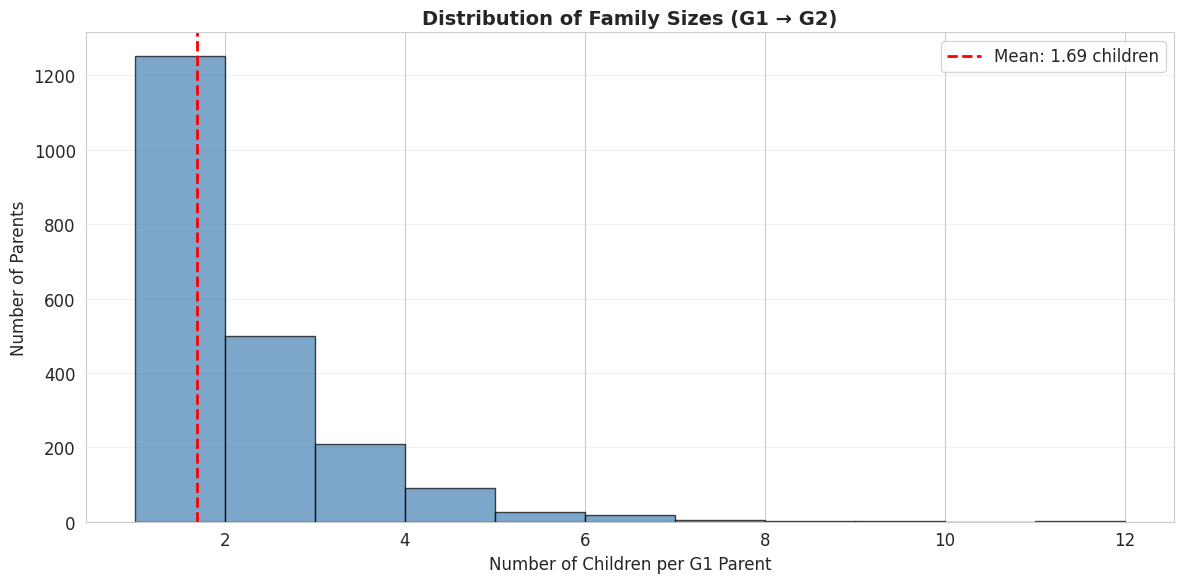

In [ ]:
# Create family size histogram
fig, ax = plt.subplots(figsize=(12, 6))

# Histogram
ax.hist(kids_per_parent['num_children'],
        bins=range(1, kids_per_parent['num_children'].max() + 2),
        edgecolor='black', alpha=0.7, color='steelblue')

# Add mean line
mean_kids = kids_per_parent['num_children'].mean()
ax.axvline(mean_kids, color='red', linestyle='--', linewidth=2,
           label=f'Mean: {mean_kids:.2f} children')

# Labels
ax.set_xlabel('Number of Children per G1 Parent', fontsize=12)
ax.set_ylabel('Number of Parents', fontsize=12)
ax.set_title('Distribution of Family Sizes (G1 → G2)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/family_size_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Plot saved")
plt.show()


## 2.3 Compare Family Size by Homeownership

**The Question:**
"Do homeowners have more or fewer children than renters?"

**Why This Matters:**
If homeowners have systematically different family sizes, that could influence our education findings.

---


📊 Family Size by Homeownership Status:

Renters:
  Mean: 1.70 children
  Median: 1 children
  Std Dev: 1.20

Owners:
  Mean: 1.69 children
  Median: 1 children
  Std Dev: 1.04



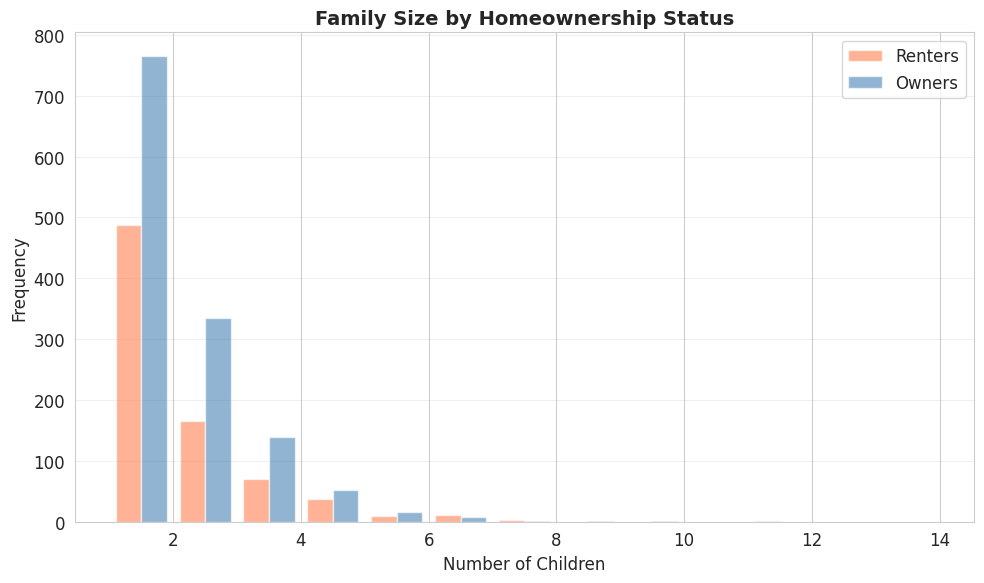

In [ ]:
# Get homeownership status for each parent
parent_hw = df[['parent_id', 'parent_homeowner']].drop_duplicates()
kids_with_owner = kids_per_parent.merge(parent_hw, on='parent_id', how='left')

# Compare family sizes
print("📊 Family Size by Homeownership Status:\n")

for status, label in [(0, "Renters"), (1, "Owners")]:
    group = kids_with_owner[kids_with_owner['parent_homeowner'] == status]['num_children']
    print(f"{label}:")
    print(f"  Mean: {group.mean():.2f} children")
    print(f"  Median: {group.median():.0f} children")
    print(f"  Std Dev: {group.std():.2f}\n")

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 6))

owners  = kids_with_owner[kids_with_owner['parent_homeowner'] == 1]['num_children']
renters = kids_with_owner[kids_with_owner['parent_homeowner'] == 0]['num_children']

ax.hist([renters, owners], label=['Renters', 'Owners'], bins=range(1, 15),
        alpha=0.6, color=['coral', 'steelblue'])
ax.set_xlabel('Number of Children', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Family Size by Homeownership Status', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


---

# Part 3: Subgroup Analyses

## The Goal

Test whether the homeownership effect differs across:
- **Race groups** (White, Black)
- **Sex** (Male vs. Female children)
- **Birth cohorts** (Different decades)

**Why This Matters:**

If the effect is much stronger (or only present) in certain groups, that tells us:
- Who benefits most from homeownership
- Whether the effect is universal
- Potential mechanisms

**Note:** Notebook 02 restricts the main analysis to White and Black families because the PSID's 1968 sample was designed around these two groups. Hispanic and Other subsamples have fewer than 20 observations each — too small for reliable subgroup regressions. We follow the same approach here.

---


## 3.1 Prepare Analysis Sample

Use the same sample restrictions as Notebook 02: White and Black families only, with non-missing education, homeownership, sex, and race.

---


In [ ]:
# ── Create analysis sample (same as Notebook 02) ──
# Restrict to White + Black (Hispanic/Other subsamples too small)
df_wb = df[df['race'].isin(['White', 'Black'])].copy()

# Drop rows missing key analysis variables
analysis_vars = ['child_educ_yrs', 'parent_homeowner', 'child_sex', 'race']
analysis_sample = df_wb.dropna(subset=analysis_vars).copy()

print(f"Full dataset:        {len(df):,}")
print(f"White + Black only:  {len(df_wb):,}")
print(f"Analysis sample:     {len(analysis_sample):,}  (non-missing on key vars)")
print(f"\nRace breakdown:")
print(analysis_sample['race'].value_counts())
print(f"\nParent homeowner:")
print(analysis_sample['parent_homeowner'].value_counts())


Full dataset:        3,560
White + Black only:  3,521
Analysis sample:     3,521  (non-missing on key vars)

Race breakdown:
race
White    2195
Black    1326
Name: count, dtype: int64

Parent homeowner:
parent_homeowner
1.0    2200
0.0    1321
Name: count, dtype: int64


## 3.2 Subgroup Analysis by Race

**The Question:**
"Does homeownership matter more for some racial groups than others?"

**How we test this:**
Run separate regressions for each race group.

**What to look for:**
- Are coefficients similar across groups?
- Is the effect significant in all groups?
- Which group benefits most?

---


In [ ]:
# ── Subgroup analysis by race ──
print("=" * 80)
print("📊 SUBGROUP ANALYSIS: BY RACE")
print("=" * 80)

results = []

for race_name in ['White', 'Black']:
    subgroup = analysis_sample[analysis_sample['race'] == race_name]

    if len(subgroup) < 30:
        print(f"\n⚠️  {race_name}: Too few observations ({len(subgroup)})")
        continue

    # Run regression: education ~ homeownership
    model = smf.ols('child_educ_yrs ~ parent_homeowner', data=subgroup).fit()

    coef = model.params['parent_homeowner']
    pval = model.pvalues['parent_homeowner']
    n = len(subgroup)

    results.append({
        'Race': race_name,
        'N': n,
        'Coefficient': round(coef, 3),
        'P-value': round(pval, 4)
    })

    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."

    print(f"\n{race_name}:")
    print(f"  N: {n:,}")
    print(f"  Homeownership Effect: {coef:.3f} years {sig}")
    print(f"  P-value: {pval:.4f}")

# Summary comparison
if results:
    results_df = pd.DataFrame(results)
    print("\n" + "=" * 80)
    print("📊 SUMMARY COMPARISON:")
    print(results_df.to_string(index=False))
    print("\n💡 Interpretation: Compare the coefficients across groups.")
    print("   Larger differences suggest the effect varies by race.")

print("\n" + "=" * 80)


📊 SUBGROUP ANALYSIS: BY RACE

White:
  N: 2,195
  Homeownership Effect: 0.590 years ***
  P-value: 0.0000

Black:
  N: 1,326
  Homeownership Effect: 0.580 years ***
  P-value: 0.0000

📊 SUMMARY COMPARISON:
 Race    N  Coefficient  P-value
White 2195         0.59      0.0
Black 1326         0.58      0.0

💡 Interpretation: Compare the coefficients across groups.
   Larger differences suggest the effect varies by race.



## 3.3 Subgroup Analysis by Sex

**The Question:**
"Does homeownership matter more for boys or girls?"

---


In [ ]:
# ── Subgroup analysis by sex ──
print("=" * 80)
print("📊 SUBGROUP ANALYSIS: BY SEX")
print("=" * 80)

for sex_code, sex_name in [(1, "Male"), (2, "Female")]:
    subgroup = analysis_sample[analysis_sample['child_sex'] == sex_code]

    model = smf.ols('child_educ_yrs ~ parent_homeowner', data=subgroup).fit()

    coef = model.params['parent_homeowner']
    pval = model.pvalues['parent_homeowner']
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."

    print(f"\n{sex_name}:")
    print(f"  N: {len(subgroup):,}")
    print(f"  Homeownership Effect: {coef:.3f} years {sig}")
    print(f"  P-value: {pval:.4f}")

print("\n" + "=" * 80)


📊 SUBGROUP ANALYSIS: BY SEX

Male:
  N: 1,508
  Homeownership Effect: 0.993 years ***
  P-value: 0.0000

Female:
  N: 2,013
  Homeownership Effect: 0.971 years ***
  P-value: 0.0000



## 3.4 Cohort Analysis by Birth Decade

**The Question:**
"Did the homeownership effect change over time?"

**Why This Matters:**

- Educational opportunities changed dramatically across decades
- Economic conditions varied
- Homeownership may have mattered more in some eras

**Note:** Remember that this sample is restricted to children aged ≥ 25 in 2023 (born ≤ 1998). The youngest cohorts will have fewer observations.

---


📊 COHORT ANALYSIS: BY BIRTH DECADE

⚠️  1930s: Too few observations (11) — skipped

1940s:
  N: 320
  Homeownership Effect: 2.164 years ***

1950s:
  N: 1,631
  Homeownership Effect: 1.124 years ***

1960s:
  N: 1,559
  Homeownership Effect: 0.655 years ***

✅ Plot saved


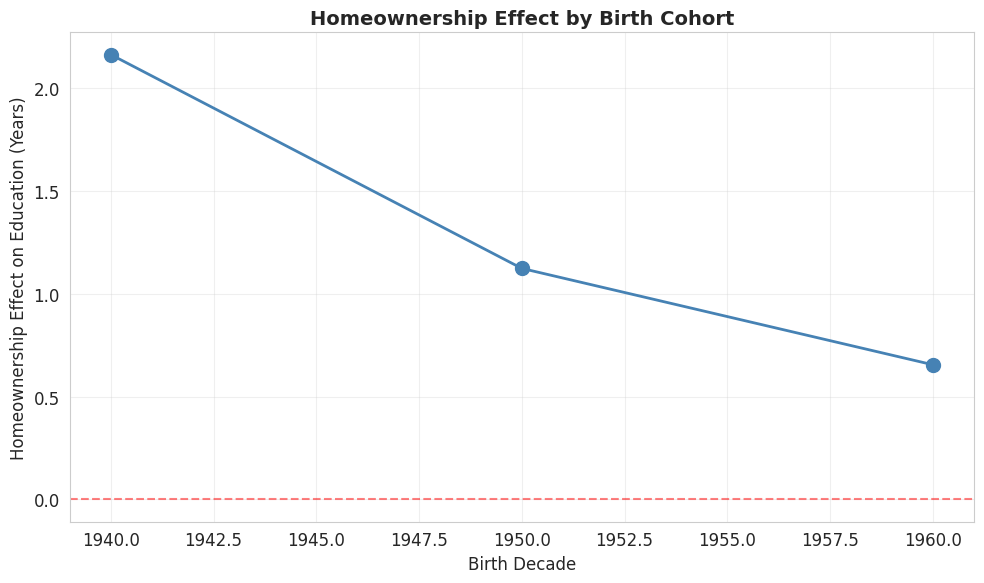

In [ ]:
# ── Cohort analysis by birth decade ──
print("=" * 80)
print("📊 COHORT ANALYSIS: BY BIRTH DECADE")
print("=" * 80)

decades = sorted(analysis_sample['birth_decade'].dropna().unique().astype(int))
results = []

for decade in decades:
    subgroup = analysis_sample[analysis_sample['birth_decade'] == decade]

    if len(subgroup) < 50:  # Skip decades with too few observations
        print(f"\n⚠️  {decade}s: Too few observations ({len(subgroup)}) — skipped")
        continue

    model = smf.ols('child_educ_yrs ~ parent_homeowner', data=subgroup).fit()

    coef = model.params['parent_homeowner']
    pval = model.pvalues['parent_homeowner']
    n = len(subgroup)

    results.append({
        'Decade': decade,
        'N': n,
        'Coefficient': coef,
        'P-value': pval
    })

    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."

    print(f"\n{decade}s:")
    print(f"  N: {n:,}")
    print(f"  Homeownership Effect: {coef:.3f} years {sig}")

# Plot trends over time
if results:
    results_df = pd.DataFrame(results)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(results_df['Decade'], results_df['Coefficient'],
            marker='o', linewidth=2, markersize=10, color='steelblue')
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Birth Decade', fontsize=12)
    ax.set_ylabel('Homeownership Effect on Education (Years)', fontsize=12)
    ax.set_title('Homeownership Effect by Birth Cohort', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/cohort_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✅ Plot saved")
    plt.show()

print("\n" + "=" * 80)


---

# Part 4: Missing Data Analysis

## The Goal

Understand who's missing from our analysis and whether missingness is systematic.

**Why This Matters:**

If data is "missing at random," our results are fine. But if missingness is systematic (e.g., all homeowners are missing education data), we could have biased results.

**Important:** For this section we load the **pre-filter** version of the data (`psid_intergenerational_clean_prefilt.csv`). This file contains all parent-child pairs aged ≥ 25 in 2023 *before* dropping rows with missing outcomes. That way we can actually see who's missing what.

---


## 4.1 Missing Data Patterns

**What we're checking:**
- Which variables have missing data?
- How much is missing?
- Is missingness related to homeownership?

---


In [ ]:
# ── Load pre-filter data for missing data analysis ──
df_prefilt = pd.read_csv(PREFILT_FILE)
print(f"Pre-filter dataset: {len(df_prefilt):,} rows")
print(f"(Main analytic sample: {len(df):,} rows)")
print(f"Difference: {len(df_prefilt) - len(df):,} rows dropped for missing data")

# ── Missing data by variable ──
print("\n" + "=" * 80)
print("📊 MISSING DATA ANALYSIS")
print("=" * 80)

key_vars = ['parent_homeowner', 'parent_educ_yrs', 'parent_income_1968',
            'child_educ_yrs', 'child_homeowner_2023', 'race', 'child_sex']

print("\n📋 Missing Data by Variable:\n")

for var in key_vars:
    if var in df_prefilt.columns:
        n_missing = df_prefilt[var].isna().sum()
        pct_missing = (n_missing / len(df_prefilt)) * 100
        print(f"{var:25s}: {n_missing:7,} missing ({pct_missing:5.1f}%)")
    else:
        print(f"{var:25s}: ⚠️  column not in pre-filter file")

print("\n" + "=" * 80)


Pre-filter dataset: 11,664 rows
(Main analytic sample: 3,560 rows)
Difference: 8,104 rows dropped for missing data

📊 MISSING DATA ANALYSIS

📋 Missing Data by Variable:

parent_homeowner         :       0 missing (  0.0%)
parent_educ_yrs          :     104 missing (  0.9%)
parent_income_1968       :       2 missing (  0.0%)
child_educ_yrs           :   8,104 missing ( 69.5%)
child_homeowner_2023     :   7,977 missing ( 68.4%)
race                     :      23 missing (  0.2%)
child_sex                :       0 missing (  0.0%)



## 4.2 Check if Missingness Relates to Homeownership

**Critical question:**
"Is education data more likely to be missing for homeowners vs. renters?"

If yes → potential bias
If no → probably okay

---


In [ ]:
# ── Does missingness relate to homeownership? ──
print("=" * 80)
print("📊 DOES MISSINGNESS RELATE TO HOMEOWNERSHIP?")
print("=" * 80)

# Only check among rows where parent_homeowner is known
df_hw_known = df_prefilt[df_prefilt['parent_homeowner'].notna()].copy()

# Create missingness indicator for child education
df_hw_known['educ_missing'] = df_hw_known['child_educ_yrs'].isna()

# Compare missingness rates
missing_by_owner = df_hw_known.groupby('parent_homeowner')['educ_missing'].mean() * 100

print("\n📋 Education Missing Rate by Homeownership:\n")
print(f"  Renters (0): {missing_by_owner.get(0, 0):.1f}% missing")
print(f"  Owners  (1): {missing_by_owner.get(1, 0):.1f}% missing")

difference = abs(missing_by_owner.get(1, 0) - missing_by_owner.get(0, 0))

if difference < 5:
    print("\n✅ GOOD: Missing rates are similar between groups")
    print("   Missingness appears to be independent of homeownership")
else:
    print("\n⚠️  WARNING: Missing rates differ substantially")
    print(f"   Difference: {difference:.1f} percentage points")
    print("   This could introduce bias into our estimates")

print("\n" + "=" * 80)


📊 DOES MISSINGNESS RELATE TO HOMEOWNERSHIP?

📋 Education Missing Rate by Homeownership:

  Renters (0): 75.3% missing
  Owners  (1): 64.5% missing

⚠️  WARNING: Missing rates differ substantially
   Difference: 10.8 percentage points
   This could introduce bias into our estimates



---

# Part 5: Robustness Checks

## The Goal

Test whether our main finding holds under different assumptions.

**Tests we'll run:**
1. Different age cutoffs (21, 23, 25, 30)
2. Full sample including Hispanic & Other (same as Notebook 02 Section 5)

**Main analysis age cutoff:** ≥ 25 (set in Notebook 01.2)

---


## 5.1 Alternative Age Cutoffs

**The Question:**
"Does our finding change if we use different age cutoffs for 'observable' education?"

**Main analysis:** Age ≥ 25 (from Notebook 01.2)
**Robustness:** Try age ≥ 21, 23, 30

We use the pre-filter file here so we can apply different age restrictions ourselves.

---


In [ ]:
# ── Robustness: alternative age cutoffs ──
# Use pre-filter data so we can apply our own age restrictions
# Derive child_age in pre-filter data
df_prefilt['child_age'] = 2023 - df_prefilt['birth_year']

# Restrict to White + Black (same as main analysis)
df_pf_wb = df_prefilt[df_prefilt['race'].isin(['White', 'Black'])].copy()

print("=" * 80)
print("📊 ROBUSTNESS: ALTERNATIVE AGE CUTOFFS")
print("=" * 80)

age_cutoffs = [21, 23, 25, 30]
results = []

for age_cutoff in age_cutoffs:
    robust_sample = df_pf_wb[
        (df_pf_wb['child_age'] >= age_cutoff) &
        (df_pf_wb['parent_homeowner'].notna()) &
        (df_pf_wb['child_educ_yrs'].notna())
    ]

    if len(robust_sample) < 100:
        print(f"\n⚠️  Age ≥ {age_cutoff}: Too few observations ({len(robust_sample)})")
        continue

    model = smf.ols('child_educ_yrs ~ parent_homeowner', data=robust_sample).fit()

    coef = model.params['parent_homeowner']
    pval = model.pvalues['parent_homeowner']
    n = len(robust_sample)

    results.append({
        'Age Cutoff': age_cutoff,
        'N': n,
        'Coefficient': round(coef, 3),
        'P-value': round(pval, 4)
    })

    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
    marker = "⭐" if age_cutoff == 25 else "  "

    print(f"\n{marker} Age ≥ {age_cutoff}:")
    print(f"   N: {n:,}")
    print(f"   Coefficient: {coef:.3f} years {sig}")

# Summary
if results:
    results_df = pd.DataFrame(results)
    print("\n" + "=" * 80)
    print("📊 SUMMARY:")
    print(results_df.to_string(index=False))
    print("\n💡 If coefficients are similar across cutoffs → Finding is ROBUST")
    print("   ⭐ = Main analysis (age ≥ 25)")

print("\n" + "=" * 80)


📊 ROBUSTNESS: ALTERNATIVE AGE CUTOFFS

   Age ≥ 21:
   N: 3,521
   Coefficient: 0.986 years ***

   Age ≥ 23:
   N: 3,521
   Coefficient: 0.986 years ***

⭐ Age ≥ 25:
   N: 3,521
   Coefficient: 0.986 years ***

   Age ≥ 30:
   N: 3,521
   Coefficient: 0.986 years ***

📊 SUMMARY:
 Age Cutoff    N  Coefficient  P-value
         21 3521        0.986      0.0
         23 3521        0.986      0.0
         25 3521        0.986      0.0
         30 3521        0.986      0.0

💡 If coefficients are similar across cutoffs → Finding is ROBUST
   ⭐ = Main analysis (age ≥ 25)



## 5.2 Full Sample Including Hispanic & Other

Same robustness check as Notebook 02 Section 5. The main analysis uses only White and Black families because the PSID's 1968 sample was designed around these two groups. Here we check whether including all races changes the result.

---


In [ ]:
# ── Full-sample robustness (all races) ──
print("=" * 80)
print("📊 ROBUSTNESS: FULL SAMPLE (ALL RACES)")
print("=" * 80)

df_full = df.dropna(subset=['child_educ_yrs', 'parent_homeowner']).copy()

print(f"\nFull sample (all races): {len(df_full):,}")
print(f"Main sample (White+Black): {len(analysis_sample):,}")
print(f"\nRace breakdown in full sample:")
print(df_full['race'].value_counts())

# Run bivariate model on full sample
model_full = smf.ols('child_educ_yrs ~ parent_homeowner', data=df_full).fit()
coef_full = model_full.params['parent_homeowner']
pval_full = model_full.pvalues['parent_homeowner']
sig = "***" if pval_full < 0.001 else "**" if pval_full < 0.01 else "*" if pval_full < 0.05 else "n.s."

# Compare to White+Black only
model_wb = smf.ols('child_educ_yrs ~ parent_homeowner', data=analysis_sample).fit()
coef_wb = model_wb.params['parent_homeowner']

print(f"\n📊 COMPARISON:")
print(f"  White+Black only:  {coef_wb:.3f} years")
print(f"  All races:         {coef_full:.3f} years {sig}")
print(f"  Difference:        {abs(coef_full - coef_wb):.3f} years")

if abs(coef_full - coef_wb) < 0.2:
    print("\n✅ Results are similar — finding is robust to sample composition")
else:
    print("\n⚠️  Results differ — sample composition matters for this estimate")

print("\n" + "=" * 80)


📊 ROBUSTNESS: FULL SAMPLE (ALL RACES)

Full sample (all races): 3,560
Main sample (White+Black): 3,521

Race breakdown in full sample:
race
White       2195
Black       1326
Hispanic      26
Other         11
Name: count, dtype: int64

📊 COMPARISON:
  White+Black only:  0.986 years
  All races:         1.010 years ***
  Difference:        0.024 years

✅ Results are similar — finding is robust to sample composition



---

# 🎯 Summary: What We Learned

Run this cell after all analyses above have completed. It prints a consolidated summary.

---


In [ ]:
print("=" * 80)
print("📊 NOTEBOOK 03 — EXPLORATION & ROBUSTNESS SUMMARY")
print("=" * 80)

print("""
This notebook tested whether the main finding from Notebook 02 —
that parental homeownership in 1968 is associated with higher child
education — holds up under closer examination.

Analyses performed:
  1. Family structure (children per parent, by homeownership)
  2. Subgroup analysis by race (White vs. Black)
  3. Subgroup analysis by sex (Male vs. Female)
  4. Cohort analysis by birth decade
  5. Missing data patterns
  6. Alternative age cutoffs (21, 23, 25, 30)
  7. Full sample including Hispanic & Other

Review the output above for each section's results.
Fill in the summary below after running all cells.
""")

print("=" * 80)
print("\nFill in after reviewing results:")
print("  Family structure:    ___")
print("  Race subgroups:      ___")
print("  Sex subgroups:       ___")
print("  Cohort trends:       ___")
print("  Missing data:        ___")
print("  Age cutoff robust:   ___")
print("  Full sample robust:  ___")
print("\n" + "=" * 80)


📊 NOTEBOOK 03 — EXPLORATION & ROBUSTNESS SUMMARY

This notebook tested whether the main finding from Notebook 02 —
that parental homeownership in 1968 is associated with higher child
education — holds up under closer examination.

Analyses performed:
  1. Family structure (children per parent, by homeownership)
  2. Subgroup analysis by race (White vs. Black)
  3. Subgroup analysis by sex (Male vs. Female)
  4. Cohort analysis by birth decade
  5. Missing data patterns
  6. Alternative age cutoffs (21, 23, 25, 30)
  7. Full sample including Hispanic & Other

Review the output above for each section's results.
Fill in the summary below after running all cells.


Fill in after reviewing results:
  Family structure:    ___
  Race subgroups:      ___
  Sex subgroups:       ___
  Cohort trends:       ___
  Missing data:        ___
  Age cutoff robust:   ___
  Full sample robust:  ___



---

## Files Generated

- `family_size_distribution.png` — Family size histogram
- `cohort_analysis.png` — Homeownership effect by birth decade

---

# End of Notebook 03

**Status:** ✅ Exploration & Robustness Complete
**Next:** Proceed to Three Generation Family Explorer

---
